### 1. Default Settings 

In [1]:
import pandas as pd 
import os 
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords 
from nltk import ngrams
from collections import Counter
import numpy as np 
from matplotlib import pyplot as plt 

counter = Counter

In [2]:
default_path = os.getcwd()
data_path = os.path.join(default_path, '../data')

In [3]:
a1 = pd.read_csv(os.path.join(data_path, 'a1_group_a.csv'))
a2 = pd.read_csv(os.path.join(data_path, 'a2_group_a.csv'))
a3 = pd.read_csv(os.path.join(data_path, 'a3_group_a.csv'))
a4 = pd.read_csv(os.path.join(data_path, 'a4_group_a.csv'))
a5 = pd.read_csv(os.path.join(data_path, 'a5_group_a.csv'))
a6 = pd.read_csv(os.path.join(data_path, 'a6_group_a.csv'))
a7 = pd.read_csv(os.path.join(data_path, 'a7_group_a.csv'))
a8 = pd.read_csv(os.path.join(data_path, 'a8_group_a.csv'))
a9 = pd.read_csv(os.path.join(data_path, 'a9_group_a.csv'))

In [4]:
data = pd.concat([a1, a2, a3, a4, a5, a6, a7, a8, a9])
data.reset_index(inplace=True, drop=True)
data.to_csv(os.path.join(data_path, 'reddit_dsm_ngram.csv'), index=False)

In [5]:
after = data.copy()
after.head(3)

,id,subreddit,author,text,type,time,parent_id,o_id,tok_len,label,group_a,group_b,group_c
0,al526,depression,unremedied,I have had all of these problems for as long a...,post,1.262551e+09,al526,al526,35,0,True,False,False
1,t3_7djh5r,depression,j0siahs74,Yes! I have been having crazy ass dreams some...,comment,1.510909e+09,t1_dpy9scj,dpy9zxp,22,0,True,False,False
2,al526,depression,unremedied,So am I depressed? I am honestly unsure mysel...,post,1.262551e+09,al526,al526,25,0,True,False,False


In [6]:
reddit = pd.read_csv(os.path.join(data_path, 'aud_dsm_label2.csv'))
reddit.head(3)

,id,subreddit,author,text,type,time,parent_id,o_id,tok_len,label
0,t3_16v6hx,depression,[deleted],if you're lonely i am find an old age pensione...,comment,1.358599e+09,t1_c7zo83f,c7zpy8m,21,0
1,t3_w6zaa,depression,throw13away,One thing that stuck out in my mind from the N...,comment,1.341807e+09,t3_w6zaa,c5bc8t2,27,0
2,t3_95ezhs,depression,pinkwav,"i feel like there's a fine line between ""depre...",comment,1.544300e+09,t1_ebcmg0f,ebdlcmq,15,0


In [8]:
reddit.groupby('label').count()

,id,subreddit,author,text,type,time,parent_id,o_id,tok_len
label,,,,,,,,,
0,515596,515596,515596,515596,515596,515596,515596,515596,515596
1,186424,186424,186424,186424,186424,186424,186424,186424,186424
2,55527,55527,55527,55527,55527,55527,55527,55527,55527
3,180213,180213,180213,180213,180213,180213,180213,180213,180213
4,4560,4560,4560,4560,4560,4560,4560,4560,4560
5,19050,19050,19050,19050,19050,19050,19050,19050,19050
6,258203,258203,258203,258203,258203,258203,258203,258203,258203
7,73640,73640,73640,73640,73640,73640,73640,73640,73640
8,299534,299534,299534,299534,299534,299534,299534,299534,299534


In [9]:
reddit = reddit[['text', 'label']]
reddit.head(3)

,text,label
0,if you're lonely i am find an old age pensione...,0
1,One thing that stuck out in my mind from the N...,0
2,"i feel like there's a fine line between ""depre...",0


In [10]:
len(reddit), len(after)

(1592747, 217351)

In [11]:
reddit.groupby('label').count()

,text
label,
0,515596
1,186424
2,55527
3,180213
4,4560
5,19050
6,258203
7,73640
8,299534


In [12]:
reddit[reddit.label==1]

,text,label
515596,"Find happiness where you can, and take the cor...",1
515597,My only pleasure in life right now is going to...,1
515598,"Live to help others, and you will find more jo...",1
515599,It's the their of joy,1
515600,"This was due to a combination of things, but p...",1
...,...,...
702015,My psychedelic experiences shoved this down my...,1
702016,that probably wont lead too their happiness an...,1
702017,I do have random bouts of happiness,1
702018,There's nothing left that gives me joy,1


In [21]:
after.groupby('label').count()

,text
label,
0,90048
1,17377
2,7666
3,27170
4,3842
5,3162
6,31355
7,6392
8,30339


In [13]:
reddit.text = reddit.text.apply(lambda x: x.replace("'m", ' am'))
reddit.text = reddit.text.apply(lambda x: x.replace("can't", "can not"))
reddit.text = reddit.text.apply(lambda x: x.replace("don't", "do not"))
reddit.text = reddit.text.apply(lambda x: x.replace("didn't", "did not"))
reddit.text = reddit.text.apply(lambda x: x.replace("doesn't", "does not"))
reddit.text = reddit.text.apply(lambda x: x.replace("couldn't", "could not"))
reddit.text = reddit.text.apply(lambda x: x.replace("haven't", "have not"))
reddit.text = reddit.text.apply(lambda x: x.replace("hasn't", "has not"))
reddit.text = reddit.text.apply(lambda x: x.replace("wouldn't", 'would not'))
reddit.text = reddit.text.apply(lambda x: x.replace("shouldn't", 'should not'))
reddit.text = reddit.text.apply(lambda x: x.replace("'re", " are"))
reddit.text = reddit.text.apply(lambda x: x.replace("'s", ' is'))
reddit.text = reddit.text.apply(lambda x: x.replace("'ve", ' have'))
reddit.text = reddit.text.apply(lambda x: x.replace(",", ' '))
reddit.text = reddit.text.apply(lambda x: x.replace("'ll", ' will'))
reddit.text = reddit.text.apply(lambda x: x.replace("wasn't", 'was not'))
reddit.text = reddit.text.apply(lambda x: x.replace("that's", "that is"))

C:\Users\lamda\AppData\Local\Temp\ipykernel_25848\3108405099.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reddit.text = reddit.text.apply(lambda x: x.replace("'m", ' am'))
C:\Users\lamda\AppData\Local\Temp\ipykernel_25848\3108405099.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reddit.text = reddit.text.apply(lambda x: x.replace("can't", "can not"))
C:\Users\lamda\AppData\Local\Temp\ipykernel_25848\3108405099.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

In [24]:
after.text = after.text.apply(lambda x: x.replace("'m", ' am'))
after.text = after.text.apply(lambda x: x.replace("can't", "can not"))
after.text = after.text.apply(lambda x: x.replace("don't", "do not"))
after.text = after.text.apply(lambda x: x.replace("didn't", "did not"))
after.text = after.text.apply(lambda x: x.replace("doesn't", "does not"))
after.text = after.text.apply(lambda x: x.replace("couldn't", "could not"))
after.text = after.text.apply(lambda x: x.replace("haven't", "have not"))
after.text = after.text.apply(lambda x: x.replace("hasn't", "has not"))
after.text = after.text.apply(lambda x: x.replace("wouldn't", 'would not'))
after.text = after.text.apply(lambda x: x.replace("shouldn't", 'should not'))
after.text = after.text.apply(lambda x: x.replace("'re", " are"))
after.text = after.text.apply(lambda x: x.replace("'s", ' is'))
after.text = after.text.apply(lambda x: x.replace("'ve", ' have'))
after.text = after.text.apply(lambda x: x.replace(",", ' '))
after.text = after.text.apply(lambda x: x.replace("'ll", ' will'))
after.text = after.text.apply(lambda x: x.replace("wasn't", 'was not'))
after.text = after.text.apply(lambda x: x.replace("that's", "that is"))

In [14]:
a1_before = reddit[reddit.label==0]
a2_before = reddit[reddit.label==1]
a3_before = reddit[reddit.label==2]
a4_before = reddit[reddit.label==3]
a5_before = reddit[reddit.label==4]
a6_before = reddit[reddit.label==5]
a7_before = reddit[reddit.label==6]
a8_before = reddit[reddit.label==7]
a9_before = reddit[reddit.label==8]

a1_before.reset_index(inplace=True, drop=True)
a2_before.reset_index(inplace=True, drop=True)
a3_before.reset_index(inplace=True, drop=True)
a4_before.reset_index(inplace=True, drop=True)
a5_before.reset_index(inplace=True, drop=True)
a6_before.reset_index(inplace=True, drop=True)
a7_before.reset_index(inplace=True, drop=True)
a8_before.reset_index(inplace=True, drop=True)
a9_before.reset_index(inplace=True, drop=True)

In [15]:
a1_after = after[after.label==0]
a2_after = after[after.label==1]
a3_after = after[after.label==2]
a4_after = after[after.label==3]
a5_after = after[after.label==4]
a6_after = after[after.label==5]
a7_after = after[after.label==6]
a8_after = after[after.label==7]
a9_after = after[after.label==8]

a1_after.reset_index(inplace=True, drop=True)
a2_after.reset_index(inplace=True, drop=True)
a3_after.reset_index(inplace=True, drop=True)
a4_after.reset_index(inplace=True, drop=True)
a5_after.reset_index(inplace=True, drop=True)
a6_after.reset_index(inplace=True, drop=True)
a7_after.reset_index(inplace=True, drop=True)
a8_after.reset_index(inplace=True, drop=True)
a9_after.reset_index(inplace=True, drop=True)

In [93]:
before_tok = []

for idx in range(len(a1_before)):
    before_tok.append(word_tokenize(a1_before.text[idx]))

In [94]:
after_tok = []

for idx in range(len(a1_after)):
    after_tok.append(word_tokenize(a1_after.text[idx]))

In [95]:
ngram = 4
before_ngram = []; after_ngram = [] 

for idx in range(len(before_tok)):
    for idx2 in range(len(list(ngrams(before_tok[idx], ngram)))):
        before_ngram.append(' '.join(list(ngrams(before_tok[idx], ngram))[idx2]))

for idx in range(len(after_tok)):
    for idx2 in range(len(list(ngrams(after_tok[idx], ngram)))):
        after_ngram.append(' '.join(list(ngrams(after_tok[idx], ngram))[idx2]))

In [96]:
before_ngrams_df = pd.DataFrame(sorted(dict(counter(before_ngram)).items(), key = lambda x: x[1], reverse=True), columns=['ngrams', 'cnt'])
after_ngrams_df = pd.DataFrame(sorted(dict(counter(after_ngram)).items(), key = lambda x: x[1], reverse=True), columns=['ngrams', 'cnt'])

In [97]:
top_before = before_ngrams_df.head(5)
top_after = after_ngrams_df.head(5)

In [98]:
top_before

,ngrams,cnt
0,I have been depressed,10929
1,I do not know,6449
2,have been depressed for,6273
3,do not want to,4326
4,I do not want,3601


In [99]:
top_after

,ngrams,cnt
0,when I am depressed,2026
1,I am depressed and,1951
2,I am still depressed,1431
3,I have been feeling,1372
4,at the same time,1218


In [100]:
top_group = top_before.merge(top_after, on='ngrams', how='outer')
top_group.fillna(0, inplace=True)
top_group.columns = ['tok', 'before', 'after']
top_group.head(3)

,tok,before,after
0,I have been depressed,10929.0,0.0
1,I do not know,6449.0,0.0
2,have been depressed for,6273.0,0.0


In [101]:
top_group

,tok,before,after
0,I have been depressed,10929.0,0.0
1,I do not know,6449.0,0.0
2,have been depressed for,6273.0,0.0
3,do not want to,4326.0,0.0
4,I do not want,3601.0,0.0
5,when I am depressed,0.0,2026.0
6,I am depressed and,0.0,1951.0
7,I am still depressed,0.0,1431.0
8,I have been feeling,0.0,1372.0
9,at the same time,0.0,1218.0


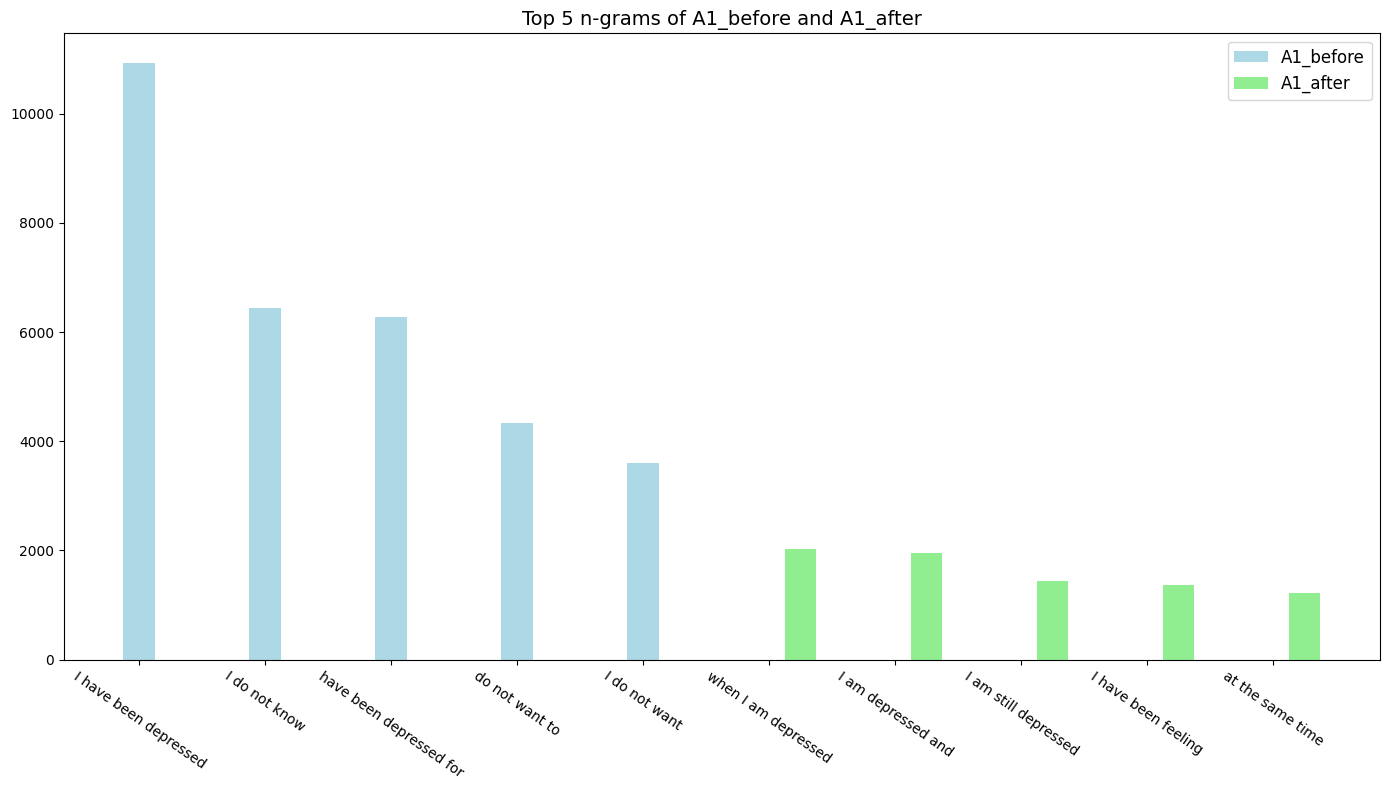

In [104]:
plt.figure(figsize=(14, 8))

index = np.arange(len(top_group))
bar_width = 0.25 

plt.bar(index, top_group.before, bar_width, color='lightblue', label='A1_before')
plt.bar(index + bar_width, top_group.after, bar_width, color='lightgreen', label='A1_after')
plt.title('Top 5 n-grams of A1_before and A1_after', fontsize=14)
plt.xticks(range(len(top_group)), top_group.tok, rotation=325)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()